In [268]:
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

In [269]:
df = pd.read_csv('german_credit_data.csv', index_col=0)
df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk
0,67,male,2,own,NaN,little,1169,6,radio/TV,good
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad
2,49,male,1,own,little,NaN,2096,12,education,good
3,45,male,2,free,little,little,7882,42,furniture/equipment,good
4,53,male,2,free,little,little,4870,24,car,bad


# Data Cleaning and EDA

In [270]:
df.shape

(1000, 10)

In [271]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column            Non-Null Count  Dtype
---  ------            --------------  -----
 0   Age               1000 non-null   int64
 1   Sex               1000 non-null   str  
 2   Job               1000 non-null   int64
 3   Housing           1000 non-null   str  
 4   Saving accounts   817 non-null    str  
 5   Checking account  606 non-null    str  
 6   Credit amount     1000 non-null   int64
 7   Duration          1000 non-null   int64
 8   Purpose           1000 non-null   str  
 9   Risk              1000 non-null   str  
dtypes: int64(4), str(6)
memory usage: 78.3 KB


In [272]:
# checking missing values

df.isnull().sum()

Age                   0
Sex                   0
Job                   0
Housing               0
Saving accounts     183
Checking account    394
Credit amount         0
Duration              0
Purpose               0
Risk                  0
dtype: int64

In [273]:
# checking duplicates

df.duplicated().sum()

np.int64(0)

In [274]:
# summary stats

df.describe()

,Age,Job,Credit amount,Duration
count,1000.000000,1000.000000,1000.000000,1000.000000
mean,35.546000,1.904000,3271.258000,20.903000
std,11.375469,0.653614,2822.736876,12.058814
min,19.000000,0.000000,250.000000,4.000000
25%,27.000000,2.000000,1365.500000,12.000000
50%,33.000000,2.000000,2319.500000,18.000000
75%,42.000000,2.000000,3972.250000,24.000000
max,75.000000,3.000000,18424.000000,72.000000


In [275]:
#getting the columnn overview

print(df['Sex'].value_counts())

print("============================")
print(df['Purpose'].value_counts())




Sex
male      690
female    310
Name: count, dtype: int64
Purpose
car                    337
radio/TV               280
furniture/equipment    181
business                97
education               59
repairs                 22
domestic appliances     12
vacation/others         12
Name: count, dtype: int64


In [276]:
df['Risk'].value_counts()

Risk
good    700
bad     300
Name: count, dtype: int64

In [277]:
df['Job'].value_counts()

Job
2    630
1    200
3    148
0     22
Name: count, dtype: int64

In [278]:
#creating job label
viz_df = df.copy()

job_mapping = {
    0: "Unemployed/Unskilled",
    1: "Unskilled",
    2: "Skilled",
    3: "Highly Skilled"
}

viz_df["Job_Label"] = viz_df["Job"].map(job_mapping)

viz_df.head()

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk,Job_Label
0,67,male,2,own,NaN,little,1169,6,radio/TV,good,Skilled
1,22,female,2,own,little,moderate,5951,48,radio/TV,bad,Skilled
2,49,male,1,own,little,NaN,2096,12,education,good,Unskilled
3,45,male,2,free,little,little,7882,42,furniture/equipment,good,Skilled
4,53,male,2,free,little,little,4870,24,car,bad,Skilled


In [279]:
df.dtypes

Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object

In [280]:
#Checking invalid values

df[df['Age'] <= 0]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk


In [281]:
df[df['Credit amount'] < 0]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk


In [282]:
df[df['Duration'] <= 0]

,Age,Sex,Job,Housing,Saving accounts,Checking account,Credit amount,Duration,Purpose,Risk


In [283]:
df['Sex'].unique()

<StringArray>
['male', 'female']
Length: 2, dtype: str

In [284]:
df['Purpose'].unique()

<StringArray>
[           'radio/TV',           'education', 'furniture/equipment',
                 'car',            'business', 'domestic appliances',
             'repairs',     'vacation/others']
Length: 8, dtype: str

In [285]:
# Handling null values

df['Checking account'] = df['Checking account'].fillna("No Account")
df['Saving accounts'] = df['Saving accounts'].fillna("No Account")

In [286]:
df['Checking account'].value_counts()




Checking account
No Account    394
little        274
moderate      269
rich           63
Name: count, dtype: int64

In [287]:
df['Saving accounts'].value_counts()

Saving accounts
little        603
No Account    183
moderate      103
quite rich     63
rich           48
Name: count, dtype: int64

<Axes: xlabel='Age', ylabel='Count'>

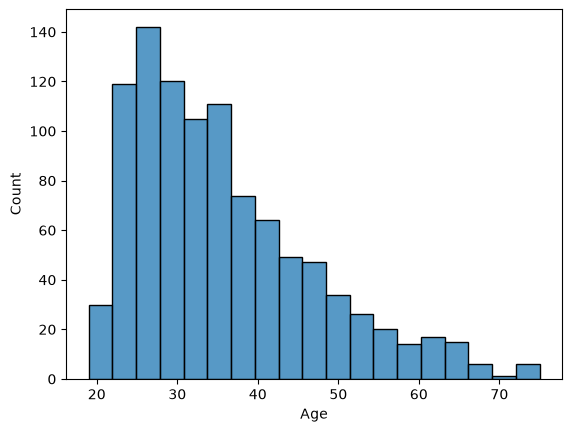

In [288]:
# Visualization

sns.histplot(df['Age'])

<Axes: xlabel='Credit amount', ylabel='Count'>

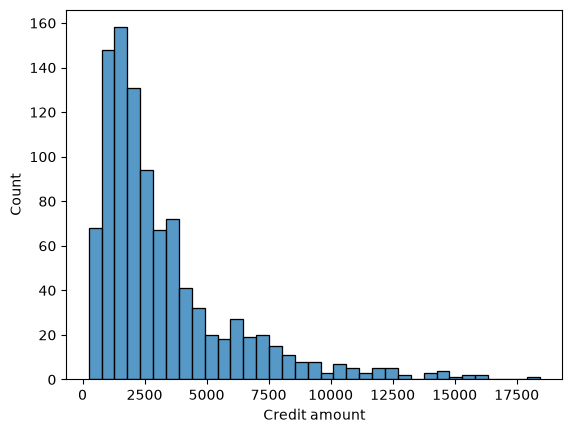

In [289]:
sns.histplot(df['Credit amount'])

<Axes: xlabel='Duration', ylabel='Count'>

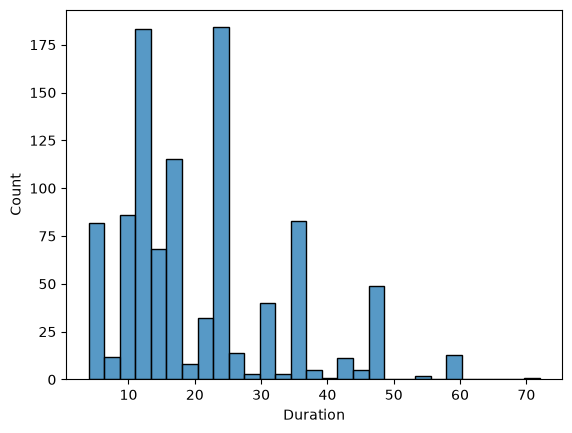

In [290]:
sns.histplot(df['Duration'])

<Axes: xlabel='count', ylabel='Sex'>

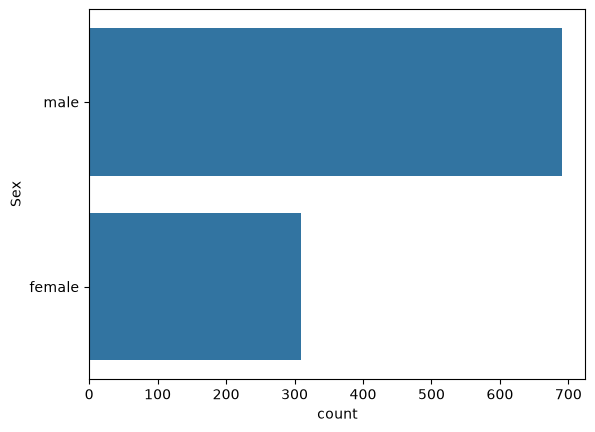

In [291]:
sns.countplot(df['Sex'])

<Axes: xlabel='count', ylabel='Risk'>

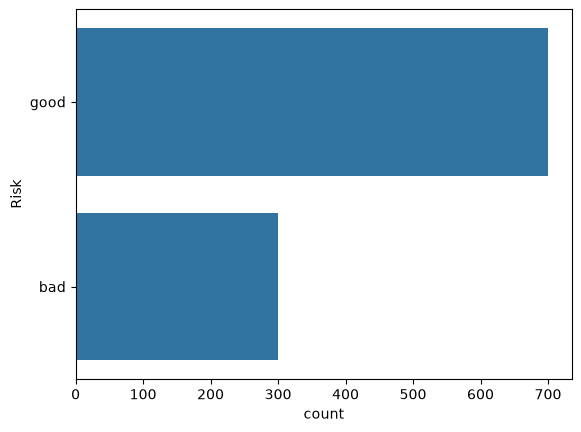

In [292]:
sns.countplot(df['Risk'])

<Axes: xlabel='count', ylabel='Housing'>

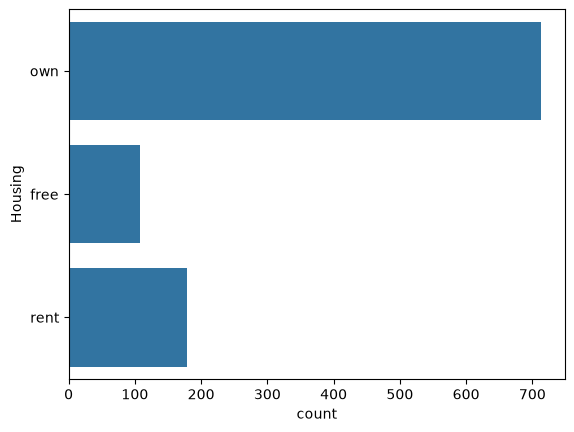

In [293]:
sns.countplot(df['Housing'])

<Axes: xlabel='count', ylabel='Saving accounts'>

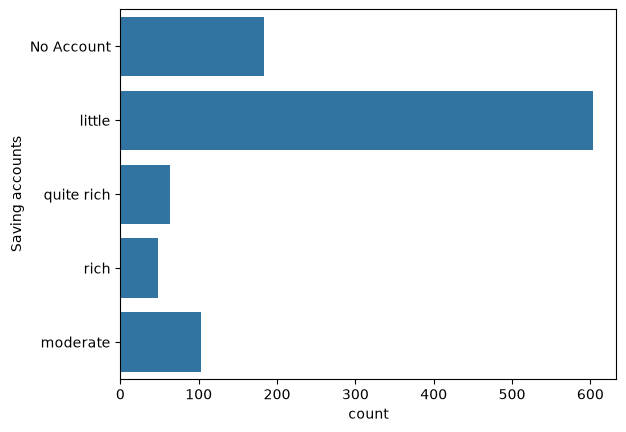

In [294]:
sns.countplot(df['Saving accounts'])

<Axes: xlabel='count', ylabel='Checking account'>

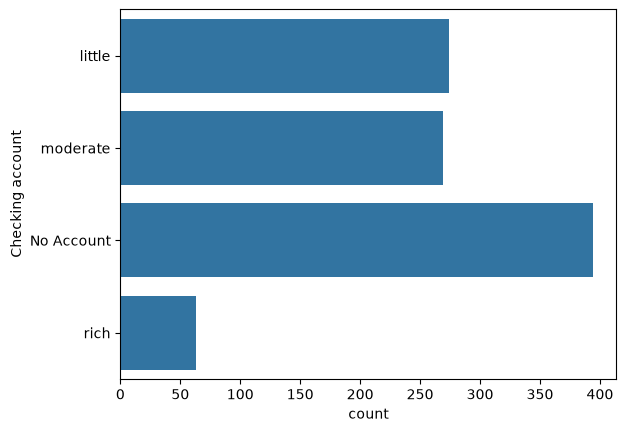

In [295]:
sns.countplot(df['Checking account'])

<Axes: xlabel='count', ylabel='Purpose'>

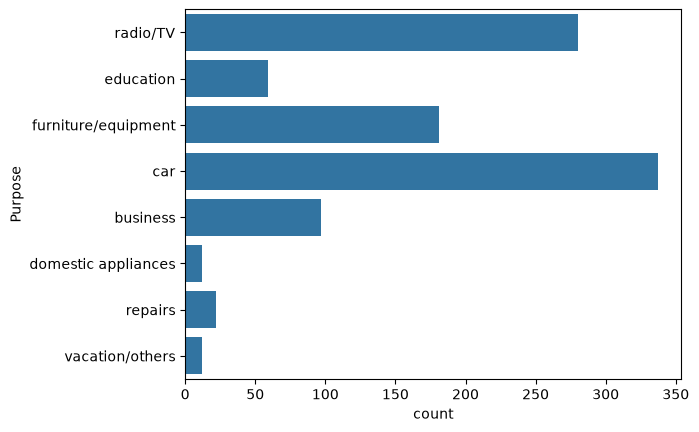

In [296]:
sns.countplot(df['Purpose'])

<Axes: xlabel='count', ylabel='Job_Label'>

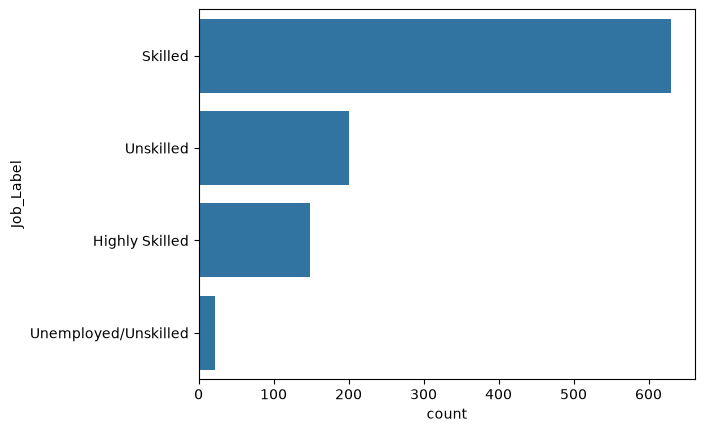

In [297]:
sns.countplot(viz_df['Job_Label'])

# Data Preprocessing

In [298]:
df.dtypes

Age                 int64
Sex                   str
Job                 int64
Housing               str
Saving accounts       str
Checking account      str
Credit amount       int64
Duration            int64
Purpose               str
Risk                  str
dtype: object

In [299]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

In [300]:
# One Hot encoding of Sex, Housing, Purpose columns

df = pd.get_dummies(
    df,
    columns= ['Sex', 'Housing', 'Purpose'],
    drop_first= True,
    dtype= int
)

df.head()

,Age,Job,Saving accounts,Checking account,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,No Account,little,1169,6,good,1,1,0,0,0,0,0,1,0,0
1,22,2,little,moderate,5951,48,bad,0,1,0,0,0,0,0,1,0,0
2,49,1,little,No Account,2096,12,good,1,1,0,0,0,1,0,0,0,0
3,45,2,little,little,7882,42,good,1,0,0,0,0,0,1,0,0,0
4,53,2,little,little,4870,24,bad,1,0,0,1,0,0,0,0,0,0


In [301]:
# Savings account mapping

saving_map = {
    "No Account": 0,
    "little": 1,
    "moderate": 2,
    "quite rich": 3,
    "rich": 4
}

df["Saving accounts"] = df["Saving accounts"].map(saving_map)

In [302]:
#Checking account mapping

checking_map = {
    "No Account": 0,
    "little": 1,
    "moderate": 2,
    "rich": 3
}

df["Checking account"] = df["Checking account"].map(checking_map)

In [303]:
# Encoding the target variable(risk)

df["Risk"] = df["Risk"].map({
    "bad": 0,
    "good": 1
})

In [304]:
df.head(10)

,Age,Job,Saving accounts,Checking account,Credit amount,Duration,Risk,Sex_male,Housing_own,Housing_rent,Purpose_car,Purpose_domestic appliances,Purpose_education,Purpose_furniture/equipment,Purpose_radio/TV,Purpose_repairs,Purpose_vacation/others
0,67,2,0,1,1169,6,1,1,1,0,0,0,0,0,1,0,0
1,22,2,1,2,5951,48,0,0,1,0,0,0,0,0,1,0,0
2,49,1,1,0,2096,12,1,1,1,0,0,0,1,0,0,0,0
3,45,2,1,1,7882,42,1,1,0,0,0,0,0,1,0,0,0
4,53,2,1,1,4870,24,0,1,0,0,1,0,0,0,0,0,0
5,35,1,0,0,9055,36,1,1,0,0,0,0,1,0,0,0,0
6,53,2,3,0,2835,24,1,1,1,0,0,0,0,1,0,0,0
7,35,3,1,2,6948,36,1,1,0,1,1,0,0,0,0,0,0
8,61,1,4,0,3059,12,1,1,1,0,0,0,0,0,1,0,0
9,28,3,1,2,5234,30,0,1,1,0,1,0,0,0,0,0,0


In [305]:
X = df.drop(columns=["Risk"])
y = df["Risk"]

In [306]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [310]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

numerical_cols = ["Age", "Credit amount", "Duration"]

X_train[numerical_cols] = scaler.fit_transform(X_train[numerical_cols])
X_test[numerical_cols] = scaler.transform(X_test[numerical_cols])

0
0
